# Module 2: Differential Expression Analysis with PyDESeq2

In this notebook we analyze a **synthetic RNA-seq experiment** inspired by a microbiology study. The experiment asks:

> Which bacterial genes change expression after 24 h in a nitrogen-limited medium compared with a rich glucose control?

The dataset contains **500 genes** measured in **10 biological samples**: 5 untreated controls and 5 nitrogen-limited cultures. Some genes were simulated to increase expression in the treated group (stress and nutrient-acquisition response), some were simulated to decrease expression (growth-associated functions), and most genes were simulated with no true change.

This gives us a controlled teaching dataset: we can learn the DESeq2 workflow while knowing that any real RNA-seq analysis would need biological annotation and experimental validation after the statistical analysis.

## Pipeline overview

```
Counts matrix + Metadata
    └─► Understand the experimental design
            └─► Explore raw counts and library sizes
                    └─► Normalize counts with size factors
                            └─► Check replicates and PCA
                                    └─► Fit the DESeq2 model
                                            └─► Interpret log2FC, p-value, and FDR
                                                    └─► Volcano plot + heatmap
```

## 0. Path configuration

We define all paths in one place so the notebook works regardless of where Jupyter was launched.

In [1]:
# Safety check — re-runs setup if variables are missing (e.g. after kernel restart)
try:
    COUNTS_FILE
    print("✓ Variables already defined")
except NameError:
    import os
    _cwd = os.getcwd()
    _module_dir = None
    for _c in [_cwd,
               os.path.join(_cwd, "modulo2_DESeq_PyDESeq2"),
               os.path.dirname(_cwd),
               os.path.join(os.path.dirname(_cwd), "modulo2_DESeq_PyDESeq2")]:
        if os.path.exists(os.path.join(_c, "data", "counts_matrix.csv")):
            _module_dir = os.path.abspath(_c)
            break
    if _module_dir is None:
        raise RuntimeError("Cannot find module directory — launch Jupyter from the repo root.")
    COUNTS_FILE = os.path.join(_module_dir, "data", "counts_matrix.csv")
    METADATA_FILE = os.path.join(_module_dir, "data", "metadata.csv")
    GENE_METADATA_FILE = os.path.join(_module_dir, "data", "gene_metadata.csv")
    RESULTS_DIR = os.path.join(_module_dir, "results")
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print(f"✓ Variables restored  |  Counts exists: {os.path.exists(COUNTS_FILE)}")

✓ Variables restored  |  Counts exists: True


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Find module directory ---
_cwd = os.getcwd()
_module_dir = None
for _c in [_cwd,
           os.path.join(_cwd, "modulo2_DESeq_PyDESeq2"),
           os.path.dirname(_cwd),
           os.path.join(os.path.dirname(_cwd), "modulo2_DESeq_PyDESeq2")]:
    if os.path.exists(os.path.join(_c, "data", "counts_matrix.csv")):
        _module_dir = os.path.abspath(_c)
        break

if _module_dir is None:
    raise RuntimeError(
        "Cannot find the module directory. "
        "Launch Jupyter from the repository root: clases-sistemas-microbiologicos/"
    )

COUNTS_FILE   = os.path.join(_module_dir, "data", "counts_matrix.csv")
METADATA_FILE = os.path.join(_module_dir, "data", "metadata.csv")
GENE_METADATA_FILE = os.path.join(_module_dir, "data", "gene_metadata.csv")
RESULTS_DIR   = os.path.join(_module_dir, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Module directory : {_module_dir}")
print(f"Counts file      : {COUNTS_FILE}  (exists: {os.path.exists(COUNTS_FILE)})")
print(f"Metadata file    : {METADATA_FILE}  (exists: {os.path.exists(METADATA_FILE)})")
print(f"Gene metadata    : {GENE_METADATA_FILE}  (exists: {os.path.exists(GENE_METADATA_FILE)})")

Module directory : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2
Counts file      : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/data/counts_matrix.csv  (exists: True)
Metadata file    : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/data/metadata.csv  (exists: True)
Gene metadata    : /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/data/gene_metadata.csv  (exists: True)


## 1. Load data

We need three inputs:

| File | Format | Description |
|---|---|---|
| `counts_matrix.csv` | genes x samples | Raw read counts per gene per sample |
| `metadata.csv` | samples x variables | Sample information: condition, replicate, medium, incubation time, and sequencing batch |
| `gene_metadata.csv` | genes x annotations | Simulated gene symbols, products, functional categories, pathways, and interpretation hints |

### Experimental design in this teaching dataset

| Group | Samples | Biological meaning |
|---|---:|---|
| `control` | 5 | Bacterial cultures grown for 24 h in rich glucose medium |
| `treated` | 5 | Matched cultures grown for 24 h in nitrogen-limited medium |

The statistical model below uses `condition` as the design factor and tests `treated` vs `control`.

**Important:** counts must be **raw integer counts**, not TPM, FPKM, CPM, or log-transformed values. DESeq2 applies its own normalization internally.

`gene_metadata.csv` is not used to fit the model. It is joined to results afterward to help interpret significant genes.

In [3]:
# Load counts matrix (genes as rows, samples as columns)
counts_raw = pd.read_csv(COUNTS_FILE, index_col="gene_id")
print(f"Counts matrix shape: {counts_raw.shape[0]} genes × {counts_raw.shape[1]} samples")
counts_raw.head()

Counts matrix shape: 500 genes × 10 samples


,ctrl_1,ctrl_2,ctrl_3,ctrl_4,ctrl_5,treat_1,treat_2,treat_3,treat_4,treat_5
gene_id,,,,,,,,,,
GENE_0001,245,134,471,482,418,260,484,498,343,229
GENE_0002,220,136,222,673,366,102,431,308,332,160
GENE_0003,55,23,257,21,101,97,112,88,23,21
GENE_0004,140,105,132,405,134,88,234,157,159,93
GENE_0005,498,606,824,1425,596,510,712,665,526,731


In [4]:
# Load metadata
metadata = pd.read_csv(METADATA_FILE)
metadata = metadata.set_index("sample_id")
print(f"Metadata shape: {metadata.shape}")
metadata

Metadata shape: (10, 5)


,condition,replicate,culture_medium,incubation_h,sequencing_batch
sample_id,,,,,
ctrl_1,control,1,rich_glucose,24,batch_1
ctrl_2,control,2,rich_glucose,24,batch_1
ctrl_3,control,3,rich_glucose,24,batch_2
ctrl_4,control,4,rich_glucose,24,batch_2
ctrl_5,control,5,rich_glucose,24,batch_3
treat_1,treated,1,nitrogen_limited,24,batch_1
treat_2,treated,2,nitrogen_limited,24,batch_1
treat_3,treated,3,nitrogen_limited,24,batch_2
treat_4,treated,4,nitrogen_limited,24,batch_2


### Gene annotation metadata

The gene annotation table gives each simulated gene a locus tag, short symbol, product description, functional category, pathway, and interpretation hint. These annotations are synthetic but mimic the kind of genome annotation table you would use with real RNA-seq results.

In [5]:
# Load gene annotations for interpretation
gene_metadata = pd.read_csv(GENE_METADATA_FILE)
gene_metadata = gene_metadata.set_index("gene_id")
print(f"Gene metadata shape: {gene_metadata.shape}")
gene_metadata.head()

Gene metadata shape: (500, 7)


,locus_tag,gene_symbol,product,functional_category,pathway,interpretation_hint,annotation_source
gene_id,,,,,,,
GENE_0001,SIM_RS00001,hk001,Conserved hypothetical protein,uncharacterized,unknown,No specific interpretation; inspect only if st...,synthetic_teaching_annotation
GENE_0002,SIM_RS00002,met002,Central metabolism enzyme,central metabolism,core metabolism,Housekeeping-like metabolic function,synthetic_teaching_annotation
GENE_0003,SIM_RS00003,abc003,ABC transporter permease,transport,membrane transport,Generic transport function,synthetic_teaching_annotation
GENE_0004,SIM_RS00004,tca004,Tricarboxylic acid cycle enzyme,energy metabolism,TCA cycle,Core energy metabolism annotation,synthetic_teaching_annotation
GENE_0005,SIM_RS00005,sec005,Protein export component,protein processing,protein secretion,Protein localization and secretion function,synthetic_teaching_annotation


### Verify sample order

Sample order must match between counts matrix and metadata — this is a common source of errors.

In [6]:
assert list(counts_raw.columns) == list(metadata.index), \
    "Sample order mismatch between counts and metadata!"
print("✓ Sample order matches")
print("Samples:", list(counts_raw.columns))

✓ Sample order matches
Samples: ['ctrl_1', 'ctrl_2', 'ctrl_3', 'ctrl_4', 'ctrl_5', 'treat_1', 'treat_2', 'treat_3', 'treat_4', 'treat_5']


## 2. Data exploration

Before fitting a model, inspect whether the data look plausible for the stated experiment:

- Do all samples have enough reads? (library size)
- Are count distributions similar across samples after accounting for sequencing depth?
- Are biological replicates more similar to each other than to the other condition?
- Does the metadata match the columns in the count matrix?

The simulated treatment effect is intentionally strong enough to be visible in quality-control plots, but the workflow is the same for real RNA-seq data.

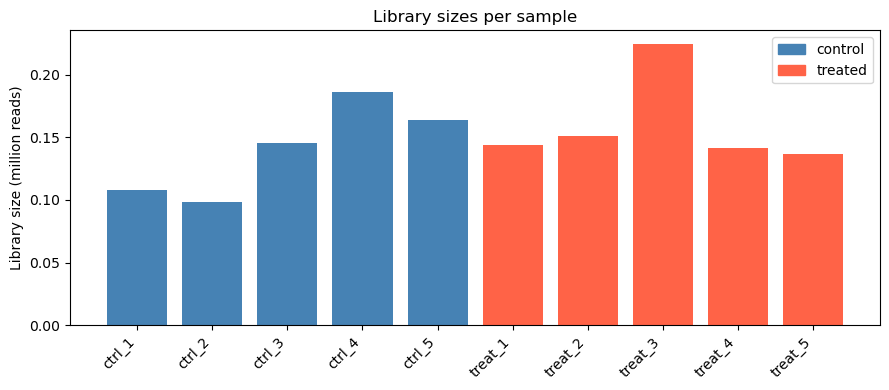

,total_counts,condition,sequencing_batch
ctrl_1,107685,control,batch_1
ctrl_2,98325,control,batch_1
ctrl_3,145508,control,batch_2
ctrl_4,186215,control,batch_2
ctrl_5,163611,control,batch_3
treat_1,143822,treated,batch_1
treat_2,151077,treated,batch_1
treat_3,224110,treated,batch_2
treat_4,141214,treated,batch_2
treat_5,136476,treated,batch_3


In [7]:
# Library sizes (total counts per sample)
library_sizes = counts_raw.sum(axis=0)
condition_palette = {"control": "steelblue", "treated": "tomato"}
sample_conditions = metadata.loc[library_sizes.index, "condition"]
colors = sample_conditions.map(condition_palette).tolist()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(library_sizes.index, library_sizes.values / 1e6, color=colors)
ax.set_ylabel("Library size (million reads)")
ax.set_title("Library sizes per sample")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=color, label=label) for label, color in condition_palette.items()])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

library_sizes.to_frame("total_counts").join(metadata[["condition", "sequencing_batch"]])

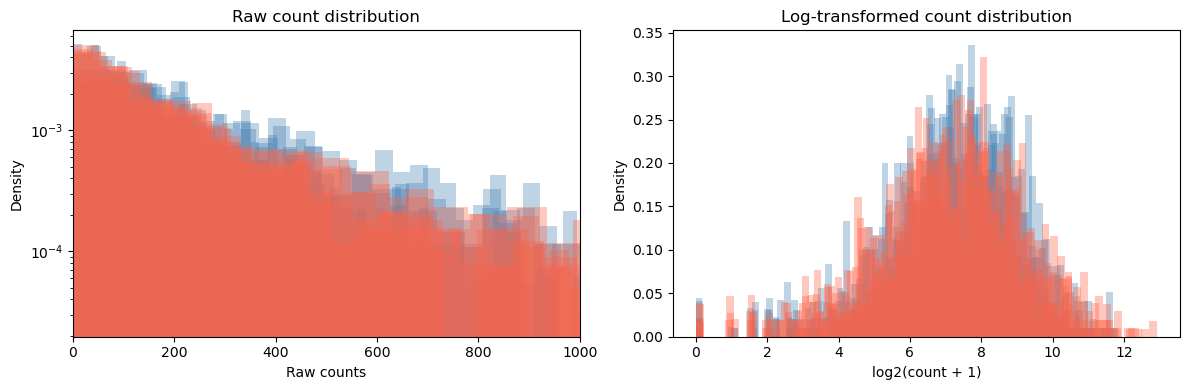

In [8]:
# Count distribution: raw counts vs log2(counts+1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts — log scale to see the full range
for col in counts_raw.columns:
    color = condition_palette[metadata.loc[col, "condition"]]
    axes[0].hist(counts_raw[col], bins=100, alpha=0.35, color=color, density=True)
axes[0].set_xlabel("Raw counts")
axes[0].set_ylabel("Density")
axes[0].set_title("Raw count distribution")
axes[0].set_yscale("log")
axes[0].set_xlim(0, 1000)

# Log2(count + 1) — more interpretable scale
for col in counts_raw.columns:
    color = condition_palette[metadata.loc[col, "condition"]]
    axes[1].hist(np.log2(counts_raw[col] + 1), bins=60, alpha=0.35, color=color, density=True)
axes[1].set_xlabel("log2(count + 1)")
axes[1].set_ylabel("Density")
axes[1].set_title("Log-transformed count distribution")

plt.tight_layout()
plt.show()

### What to look for

- Raw counts follow a **negative binomial distribution**: many low-count genes, few highly expressed ones.
- After log₂ transform, the distribution looks roughly normal — easier to interpret.
- Library sizes should be similar across samples. Large differences indicate a potential normalization issue.

## 3. Normalization and size factors

Different samples have different **library sizes** (total reads sequenced). To compare gene expression across samples, we need to normalize.

### DESeq2 normalization: median-of-ratios

1. Compute a **pseudo-reference** sample: for each gene, take the geometric mean across all samples.
2. For each sample, compute the **ratio** of each gene to its pseudo-reference value.
3. The **size factor** for a sample is the **median** of these ratios.
4. Divide counts by the size factor to obtain normalized counts.

This approach is robust to highly expressed genes (outliers don't dominate the median).

> **Why not just divide by library size (CPM)?** CPM is sensitive to highly expressed genes that dominate the library. If one gene is 80% of reads in one sample but not another, all other genes will appear artificially downregulated in that sample.

In [9]:
# Manual computation of DESeq2 size factors (for teaching)

# Step 1: Keep only genes with non-zero counts in all samples
counts_nonzero = counts_raw[(counts_raw > 0).all(axis=1)]
print(f"Genes with non-zero counts in all samples: {len(counts_nonzero)}")

# Step 2: Pseudo-reference = geometric mean per gene
log_counts_nz = np.log(counts_nonzero)  # natural log
geo_mean = np.exp(log_counts_nz.mean(axis=1))

# Step 3: Ratio of each sample to pseudo-reference
ratios = counts_nonzero.div(geo_mean, axis=0)

# Step 4: Size factor = median ratio per sample
size_factors = ratios.median(axis=0)
print("\nSize factors:")
for s, sf in size_factors.items():
    print(f"  {s}: {sf:.4f}")

# Normalize
counts_norm = counts_raw.div(size_factors, axis=1)
print("\n✓ Normalized counts computed")
print(f"\nMean library size before normalization: {counts_raw.sum(axis=0).mean():.0f}")
print(f"Mean library size after normalization:  {counts_norm.sum(axis=0).mean():.0f}")

Genes with non-zero counts in all samples: 483

Size factors:
  ctrl_1: 0.8536
  ctrl_2: 0.7996
  ctrl_3: 1.1157
  ctrl_4: 1.4748
  ctrl_5: 1.3031
  treat_1: 0.8962
  treat_2: 0.9367
  treat_3: 1.3846
  treat_4: 0.8752
  treat_5: 0.8519

✓ Normalized counts computed

Mean library size before normalization: 149804
Mean library size after normalization:  143653


## 4. Biological replicates

**Replicates** are essential for statistical inference. Without replicates, it is impossible to distinguish real biological differences from technical noise.

This dataset now has **5 biological replicates per condition**, which is still small by production RNA-seq standards but much better for teaching than a 3 vs 3 design.

### Why more replicates help

- 2 replicates: you can estimate the mean but not the variance reliably.
- 3 replicates: a minimal design for dispersion estimation.
- 5+ replicates: better variance estimates and more power to detect moderate fold changes.

A good sanity check: **replicates within the same condition should correlate more strongly with each other than with samples from the other condition**.

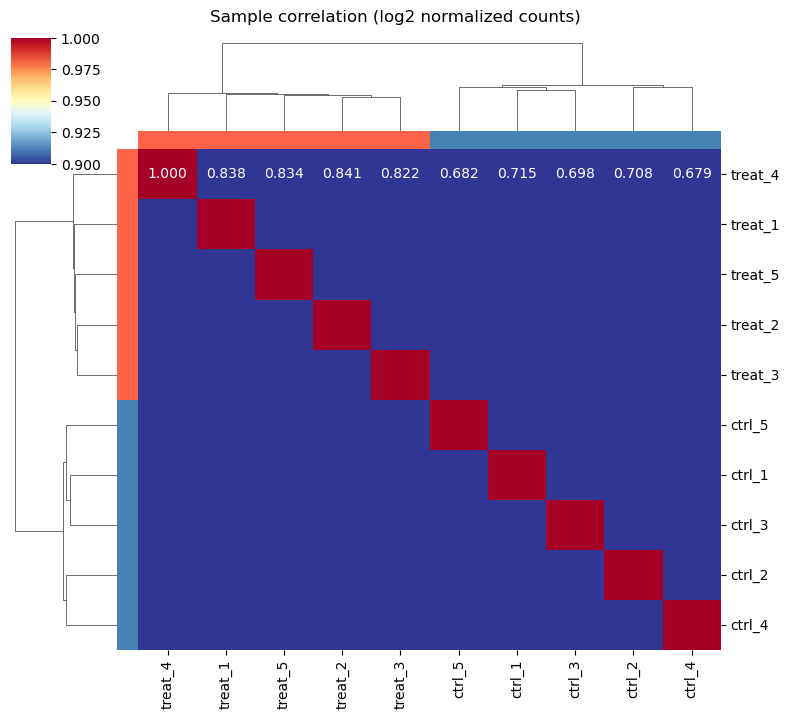

In [10]:
# Correlation matrix of log-normalized counts
log_norm = np.log2(counts_norm + 1)
corr = log_norm.corr()

# Sample annotation for color bars
condition_colors = metadata.loc[corr.columns, "condition"].map(condition_palette).tolist()

g = sns.clustermap(
    corr,
    cmap="RdYlBu_r",
    vmin=0.90, vmax=1.0,
    annot=True, fmt=".3f",
    figsize=(8, 7),
    col_colors=[condition_colors],
    row_colors=[condition_colors],
    dendrogram_ratio=0.15
)
g.figure.suptitle("Sample correlation (log2 normalized counts)", y=1.02)
plt.show()

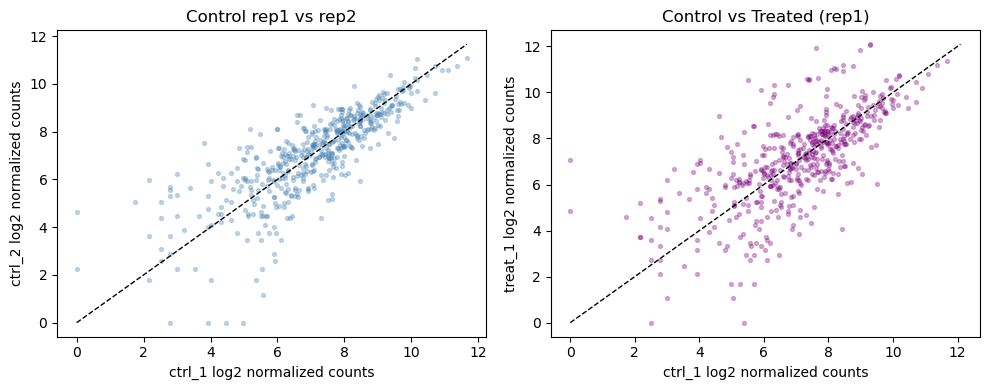

In [11]:
# Replicate-vs-replicate scatter plots
# Within-condition variation should be smaller than the treatment signal.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pairs = [("ctrl_1", "ctrl_2", "Control rep1 vs rep2", "steelblue"),
         ("ctrl_1", "treat_1", "Control vs Treated (rep1)", "purple")]

for ax, (s1, s2, title, color) in zip(axes, pairs):
    x = np.log2(counts_norm[s1] + 1)
    y = np.log2(counts_norm[s2] + 1)
    ax.scatter(x, y, alpha=0.3, s=8, color=color)
    lim = [0, max(x.max(), y.max())]
    ax.plot(lim, lim, "--", color="black", lw=1)
    ax.set_xlabel(f"{s1} log2 normalized counts")
    ax.set_ylabel(f"{s2} log2 normalized counts")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### What to look for

- Replicates within the same condition should show high correlation and fall close to the diagonal.
- Between conditions, genes that deviate from the diagonal are potential DE genes.
- The treatment effect should not be confused with sequencing batch. In real projects, batch should be included in the model when the design and sample size support it.

## 5. Exploratory PCA

**PCA (Principal Component Analysis)** reduces high-dimensional count data to 2-3 dimensions for visualization.

### What to expect
- Samples from the same condition should cluster together.
- The main axis of variation (PC1) should separate conditions if there is a real treatment effect.
- Outlier samples that don't cluster with their group may need to be investigated.

### VST transformation
Before PCA, we apply a **Variance-Stabilizing Transformation** (VST) to make the variance independent of the mean. Here we use log₂(normalized + 1) as an approximation.

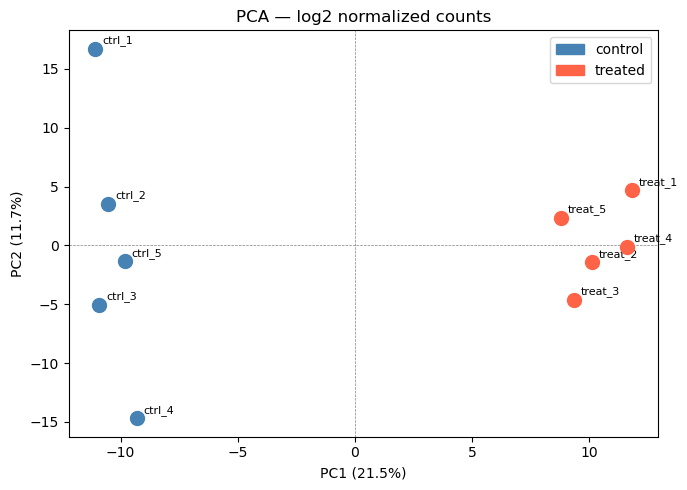

,sample_id,condition,PC1,PC2
0,ctrl_1,control,-11.074159,16.700623
1,ctrl_2,control,-10.535880,3.538106
2,ctrl_3,control,-10.923596,-5.067634
3,ctrl_4,control,-9.308587,-14.689202
4,ctrl_5,control,-9.823284,-1.351903
5,treat_1,treated,11.798233,4.670979
6,treat_2,treated,10.119732,-1.450830
7,treat_3,treated,9.353728,-4.610858
8,treat_4,treated,11.614293,-0.104713
9,treat_5,treated,8.779520,2.365433


In [12]:
# PCA on log-normalized counts (samples as rows, genes as columns)
X = log_norm.T.values  # shape: (n_samples, n_genes)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=4)
pca_coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

# Color by condition
sample_names = list(counts_norm.columns)
conditions = metadata.loc[sample_names, "condition"].values
colors_pca = [condition_palette[c] for c in conditions]

fig, ax = plt.subplots(figsize=(7, 5))
for i, sample in enumerate(sample_names):
    ax.scatter(pca_coords[i, 0], pca_coords[i, 1],
               color=colors_pca[i], s=100, zorder=3)
    ax.annotate(sample, (pca_coords[i, 0], pca_coords[i, 1]),
                textcoords="offset points", xytext=(5, 4), fontsize=8)

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title("PCA — log2 normalized counts")
ax.legend(handles=[Patch(color=color, label=label) for label, color in condition_palette.items()])
plt.tight_layout()
plt.show()

pd.DataFrame({
    "sample_id": sample_names,
    "condition": conditions,
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
})

## 6. Differential expression with PyDESeq2

**DESeq2** fits a **Negative Binomial GLM** (Generalized Linear Model) for each gene, modeling:

- The expected count as a function of condition
- Gene-specific dispersion (biological variability)
- Library-size differences through size factors

For this introductory module, the model is:

```text
count ~ condition
```

The contrast is `treated / control`, so positive log2 fold changes mean higher expression in nitrogen-limited cultures.

### Steps performed internally

1. **Estimate size factors** (normalization)
2. **Estimate gene-wise dispersions** (variance per gene)
3. **Shrink dispersions** toward a fitted trend (to stabilize estimates for low-count genes)
4. **Fit the GLM** and test using a Wald test
5. **Adjust p-values** to control FDR

In [13]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# PyDESeq2 expects:
#   counts: DataFrame with samples as ROWS and genes as COLUMNS
#   metadata: DataFrame with samples as rows
counts_for_deseq = counts_raw.T  # transpose: now (n_samples, n_genes)
print(f"Counts shape for DeseqDataSet: {counts_for_deseq.shape}  (samples × genes)")

# Create the DeseqDataSet
dds = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
    quiet=False
)

print("\n✓ DeseqDataSet created")

Counts shape for DeseqDataSet: (10, 500)  (samples × genes)

✓ DeseqDataSet created


In [14]:
# Run the full DESeq2 pipeline
# This estimates dispersions and fits the model
dds.deseq2()
print("\n✓ DESeq2 model fitted")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.09 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...



✓ DESeq2 model fitted


... done in 0.06 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [15]:
# Extract results for the contrast: treated vs control
stat_res = DeseqStats(
    dds,
    contrast=("condition", "treated", "control"),
    alpha=0.05  # FDR threshold used for independent filtering
)
stat_res.summary()

results = stat_res.results_df.copy()
results_annotated = results.join(gene_metadata, how="left")

print(f"\nTotal genes tested: {len(results)}")
results_annotated[[
    "gene_symbol", "product", "functional_category", "pathway",
    "baseMean", "log2FoldChange", "pvalue", "padj"
]].head(10)

Log2 fold change & Wald test p-value: condition treated vs control
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                   
GENE_0001  335.156531        0.259799  0.290191  0.895270  3.706429e-01   
GENE_0002  272.753443       -0.002546  0.377894 -0.006738  9.946242e-01   
GENE_0003   75.758632       -0.279106  0.650651 -0.428964  6.679492e-01   
GENE_0004  154.331381       -0.075003  0.382232 -0.196223  8.444353e-01   
GENE_0005  677.195975       -0.101095  0.251581 -0.401838  6.878035e-01   
...               ...             ...       ...       ...           ...   
GENE_0496  523.980308        3.508404  0.613304  5.720497  1.062132e-08   
GENE_0497  218.015478        0.038318  0.334255  0.114638  9.087324e-01   
GENE_0498   71.631461       -0.662189  0.494759 -1.338407  1.807638e-01   
GENE_0499  244.362774       -0.796532  0.286415 -2.781039  5.418521e-03   
GENE_0500  454.369694        0.08

Running Wald tests...
... done in 0.07 seconds.



,gene_symbol,product,functional_category,pathway,baseMean,log2FoldChange,pvalue,padj
gene_id,,,,,,,,
GENE_0001,hk001,Conserved hypothetical protein,uncharacterized,unknown,335.156531,0.259799,0.370643,0.750172
GENE_0002,met002,Central metabolism enzyme,central metabolism,core metabolism,272.753443,-0.002546,0.994624,0.994741
GENE_0003,abc003,ABC transporter permease,transport,membrane transport,75.758632,-0.279106,0.667949,0.869827
GENE_0004,tca004,Tricarboxylic acid cycle enzyme,energy metabolism,TCA cycle,154.331381,-0.075003,0.844435,0.943467
GENE_0005,sec005,Protein export component,protein processing,protein secretion,677.195975,-0.101095,0.687803,0.874480
GENE_0006,rec006,DNA repair protein,replication and repair,DNA repair,270.903325,-0.441677,0.125213,0.473944
GENE_0007,lip007,Lipid metabolism enzyme,lipid metabolism,membrane lipid metabolism,229.586892,0.152607,0.720196,0.887353
GENE_0008,tf008,Transcriptional regulator,regulation,transcription regulation,56.740314,-0.531490,0.433817,0.787181
GENE_0009,pep009,Peptidase family protein,protein turnover,proteolysis,112.324952,0.339846,0.504026,0.834570


### Results table columns

| Column | Description |
|---|---|
| `baseMean` | Mean normalized count across all samples |
| `log2FoldChange` | log₂(treated / control) — positive = up in treated |
| `lfcSE` | Standard error of the log2FC estimate |
| `stat` | Wald statistic |
| `pvalue` | Raw p-value from Wald test |
| `padj` | Adjusted p-value (Benjamini-Hochberg FDR) |

### log2 fold change interpretation

| log2FC | Fold change | Direction |
|---|---|---|
| +1 | 2× | up in treated |
| +2 | 4× | up in treated |
| -1 | 0.5× (2× down) | down in treated |
| -2 | 0.25× (4× down) | down in treated |

## 7. P-value and FDR

### p-value
The probability of observing a fold change as extreme as the one measured **by chance** (if the null hypothesis H₀ = "no difference" is true).

### Multiple testing problem
We test ~500 genes simultaneously. If α = 0.05, we expect 0.05 × 500 = **25 false positives by chance**.

### FDR (False Discovery Rate) — Benjamini-Hochberg correction
Instead of controlling the probability of any false positive (FWER), FDR controls the **expected fraction of false positives among all discoveries**.

- `padj < 0.05` means: among all genes called significant, at most 5% are expected to be false positives.
- Much more powerful than Bonferroni correction for genomics data.

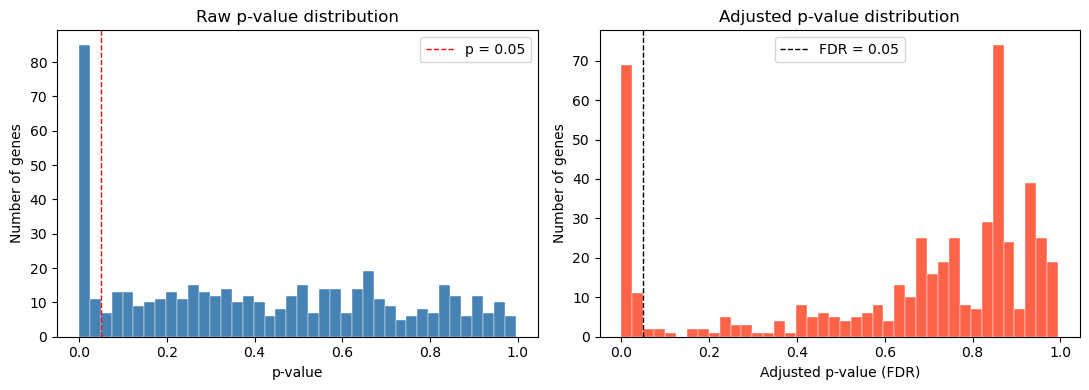

Significant genes (FDR < 0.05): 80
  Up-regulated in treated:       45
  Down-regulated in treated:     35


In [16]:
# P-value distribution
# Under H0 (no DE), p-values are uniformly distributed.
# A spike near 0 indicates true signal.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pvals = results["pvalue"].dropna()
padj  = results["padj"].dropna()

axes[0].hist(pvals, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Number of genes")
axes[0].set_title("Raw p-value distribution")
axes[0].axvline(0.05, color="red", ls="--", lw=1, label="p = 0.05")
axes[0].legend()

axes[1].hist(padj, bins=40, color="tomato", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Adjusted p-value (FDR)")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Adjusted p-value distribution")
axes[1].axvline(0.05, color="black", ls="--", lw=1, label="FDR = 0.05")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pvalue_distribution.png"), dpi=150)
plt.show()

n_sig = (padj < 0.05).sum()
n_up  = ((padj < 0.05) & (results.loc[padj.index, "log2FoldChange"] > 0)).sum()
n_dn  = ((padj < 0.05) & (results.loc[padj.index, "log2FoldChange"] < 0)).sum()
print(f"Significant genes (FDR < 0.05): {n_sig}")
print(f"  Up-regulated in treated:       {n_up}")
print(f"  Down-regulated in treated:     {n_dn}")

In [17]:
# Filter significant DE genes
LFC_THRESHOLD = 1.0   # |log2FC| > 1 means >= 2x fold change
FDR_THRESHOLD = 0.05

sig_genes = results_annotated[
    (results_annotated["padj"] < FDR_THRESHOLD) &
    (results_annotated["log2FoldChange"].abs() > LFC_THRESHOLD)
].copy()

sig_genes = sig_genes.sort_values("padj")
print(f"DE genes (|log2FC| > {LFC_THRESHOLD} AND FDR < {FDR_THRESHOLD}): {len(sig_genes)}")
print(f"  Up-regulated:   {(sig_genes['log2FoldChange'] > 0).sum()}")
print(f"  Down-regulated: {(sig_genes['log2FoldChange'] < 0).sum()}")
print("\nTop 10 most significant DE genes with annotations:")
sig_genes[[
    "gene_symbol", "product", "functional_category", "pathway",
    "log2FoldChange", "pvalue", "padj", "interpretation_hint"
]].head(10)

DE genes (|log2FC| > 1.0 AND FDR < 0.05): 77
  Up-regulated:   44
  Down-regulated: 33

Top 10 most significant DE genes with annotations:


,gene_symbol,product,functional_category,pathway,log2FoldChange,pvalue,padj,interpretation_hint
gene_id,,,,,,,,
GENE_0177,ntr177,Nitrogen regulatory protein,regulation,nitrogen response,3.095081,5.902233e-44,2.945214e-41,Candidate regulator activated during nitrogen ...
GENE_0235,gln235,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,2.845681,3.497028e-40,8.725086e-38,Supports assimilation of limited nitrogen sources
GENE_0468,nas468,Nitrate/nitrite assimilation protein,energy and nutrient metabolism,nitrogen assimilation,3.218068,7.708399e-39,1.282164e-36,Consistent with use of alternative nitrogen so...
GENE_0196,nas196,Nitrate/nitrite assimilation protein,energy and nutrient metabolism,nitrogen assimilation,3.149340,4.574236e-35,5.706360e-33,Consistent with use of alternative nitrogen so...
GENE_0283,gln283,Glutamine synthetase family enzyme,amino acid metabolism,nitrogen assimilation,4.082106,3.054868e-32,3.048758e-30,Supports assimilation of limited nitrogen sources
GENE_0180,nas180,Nitrate/nitrite assimilation protein,energy and nutrient metabolism,nitrogen assimilation,3.407404,1.355151e-29,1.127034e-27,Consistent with use of alternative nitrogen so...
GENE_0265,rpl265,Large ribosomal subunit protein,translation,ribosome,-3.021745,6.665643e-28,4.751651e-26,Lower expression can indicate slower growth
GENE_0473,ntr473,Nitrogen regulatory protein,regulation,nitrogen response,2.455158,2.625732e-26,1.637800e-24,Candidate regulator activated during nitrogen ...
GENE_0377,ntr377,Nitrogen regulatory protein,regulation,nitrogen response,2.822928,7.341637e-25,4.070530e-23,Candidate regulator activated during nitrogen ...


In [18]:
# Save full results and significant genes to CSV
results.to_csv(os.path.join(RESULTS_DIR, "deseq2_results_all.csv"))
results_annotated.to_csv(os.path.join(RESULTS_DIR, "deseq2_results_all_annotated.csv"))
sig_genes.to_csv(os.path.join(RESULTS_DIR, "deseq2_results_significant_annotated.csv"))

# Keep the original significant-results filename for compatibility.
sig_genes[results.columns].to_csv(os.path.join(RESULTS_DIR, "deseq2_results_significant.csv"))

print(f"Full results saved to: {RESULTS_DIR}/deseq2_results_all.csv")
print(f"Annotated full results saved to: {RESULTS_DIR}/deseq2_results_all_annotated.csv")
print(f"Annotated significant genes saved to: {RESULTS_DIR}/deseq2_results_significant_annotated.csv")

Full results saved to: /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/results/deseq2_results_all.csv
Annotated full results saved to: /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/results/deseq2_results_all_annotated.csv
Annotated significant genes saved to: /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/results/deseq2_results_significant_annotated.csv


## 8. Volcano plot

The **volcano plot** visualizes both **effect size** (log2FC on x-axis) and **statistical significance** (-log10(padj) on y-axis) for all genes simultaneously.

- Top-right: significantly up-regulated in treated
- Top-left: significantly down-regulated in treated
- Bottom center: not significant (low fold change or low confidence)

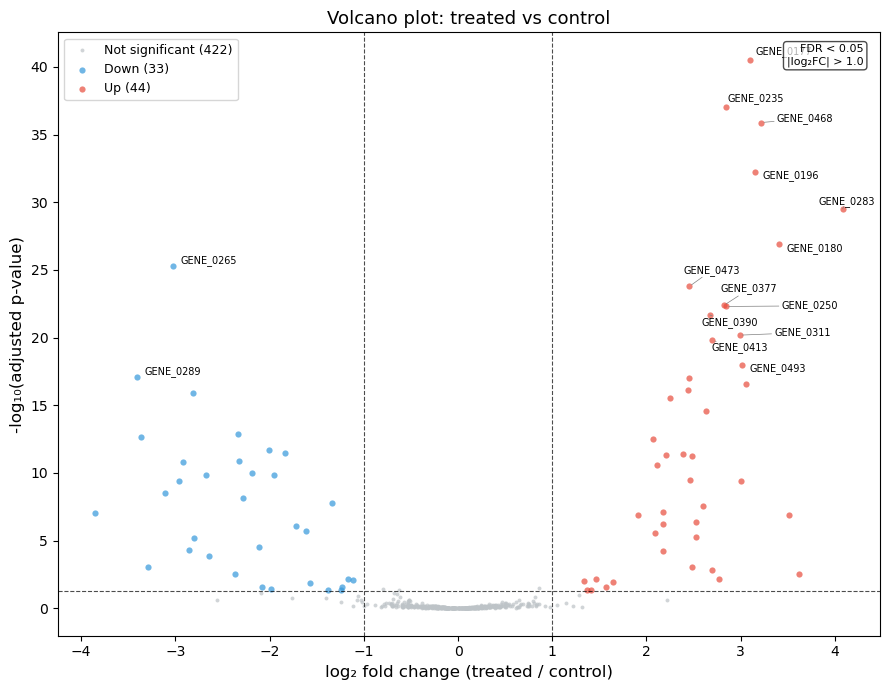

In [19]:
from adjustText import adjust_text

res_plot = results.dropna(subset=["padj", "log2FoldChange"]).copy()
res_plot["neg_log10_padj"] = -np.log10(res_plot["padj"].clip(lower=1e-300))

# Categorize genes
def classify(row):
    if row["padj"] < FDR_THRESHOLD and row["log2FoldChange"] > LFC_THRESHOLD:
        return "up"
    elif row["padj"] < FDR_THRESHOLD and row["log2FoldChange"] < -LFC_THRESHOLD:
        return "down"
    else:
        return "ns"

res_plot["category"] = res_plot.apply(classify, axis=1)
color_map = {"up": "#e74c3c", "down": "#3498db", "ns": "#bdc3c7"}
size_map  = {"up": 20, "down": 20, "ns": 8}

fig, ax = plt.subplots(figsize=(9, 7))

for cat in ["ns", "down", "up"]:
    sub = res_plot[res_plot["category"] == cat]
    label = {"up": f"Up ({(res_plot['category']=='up').sum()})",
             "down": f"Down ({(res_plot['category']=='down').sum()})",
             "ns": f"Not significant ({(res_plot['category']=='ns').sum()})"}[cat]
    ax.scatter(sub["log2FoldChange"], sub["neg_log10_padj"],
               c=color_map[cat], s=size_map[cat], alpha=0.7, label=label, linewidths=0)

# Threshold lines
ax.axhline(-np.log10(FDR_THRESHOLD), color="black", ls="--", lw=0.8, alpha=0.7)
ax.axvline( LFC_THRESHOLD, color="black", ls="--", lw=0.8, alpha=0.7)
ax.axvline(-LFC_THRESHOLD, color="black", ls="--", lw=0.8, alpha=0.7)

# Label top genes
top_genes = res_plot[res_plot["category"] != "ns"].nlargest(15, "neg_log10_padj")
texts = []
for _, row in top_genes.iterrows():
    texts.append(ax.text(row["log2FoldChange"], row["neg_log10_padj"],
                         row.name, fontsize=7))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlabel("log₂ fold change (treated / control)", fontsize=12)
ax.set_ylabel("-log₁₀(adjusted p-value)", fontsize=12)
ax.set_title("Volcano plot: treated vs control", fontsize=13)
ax.legend(loc="upper left", fontsize=9)

# Annotation
ax.text(0.98, 0.98, f"FDR < {FDR_THRESHOLD}\n|log₂FC| > {LFC_THRESHOLD}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "volcano_plot.png"), dpi=150)
plt.show()

## 9. Heatmap of top DE genes

A heatmap displays expression levels across all samples for a selected set of genes, with hierarchical clustering applied to both genes and samples.

We use **z-scores** (standardized within each gene) to highlight relative expression differences, not absolute values.

Plotting top 50 DE genes


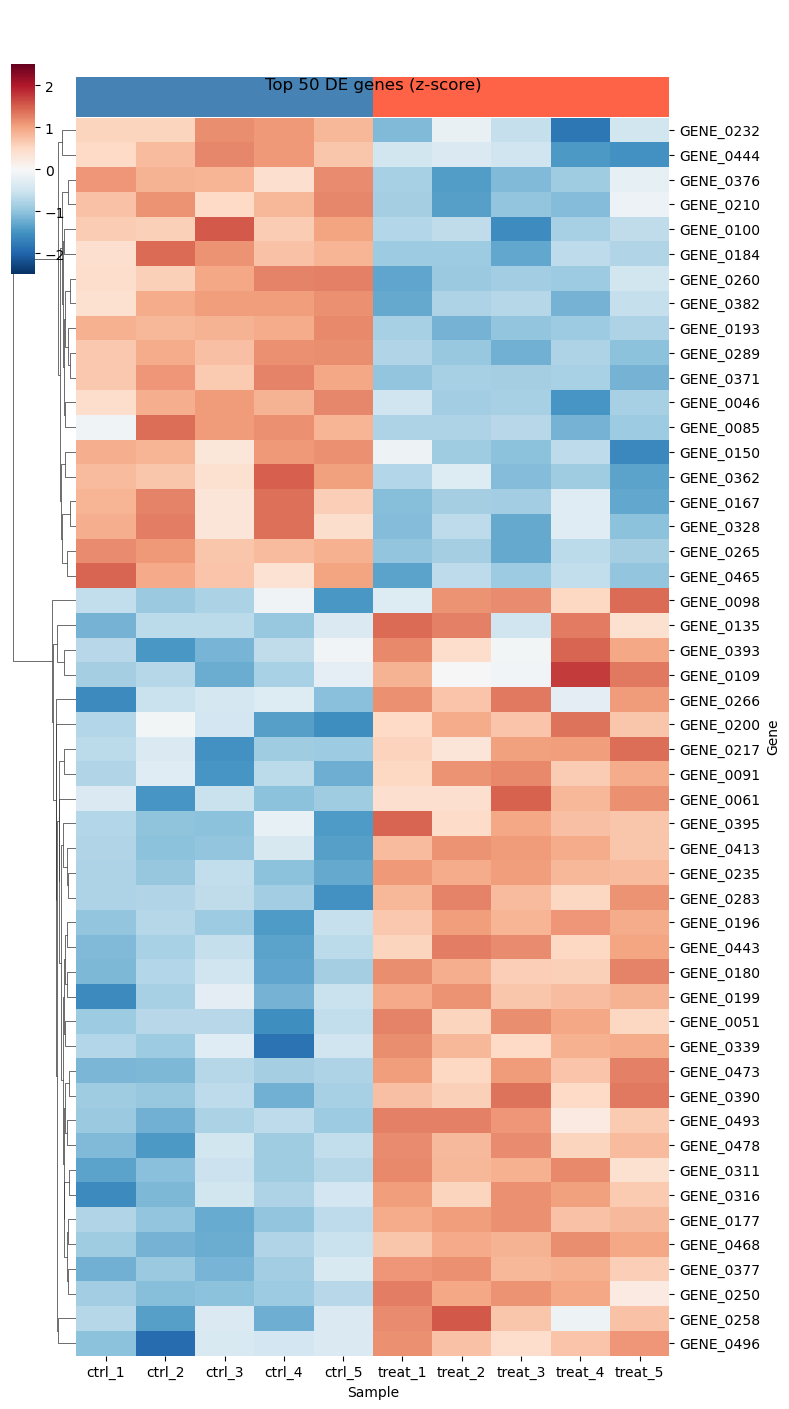

Blue = control, Red = treated  |  Color scale = z-score


In [20]:
# Select top 50 DE genes by adjusted p-value
top_de = sig_genes.nsmallest(50, "padj").index.tolist()
# Fall back to all sig genes if fewer than 50
if len(top_de) == 0:
    top_de = results.dropna(subset=["padj"]).nsmallest(50, "padj").index.tolist()

print(f"Plotting top {len(top_de)} DE genes")

# Extract log-normalized expression for these genes
heatmap_data = log_norm.loc[top_de]  # shape: (n_genes, n_samples)

# Z-score across samples (per gene)
heatmap_z = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
heatmap_z = heatmap_z.divide(heatmap_data.std(axis=1).replace(0, 1), axis=0)

# Column annotation
col_colors = ["steelblue" if "ctrl" in c else "tomato" for c in heatmap_z.columns]

g = sns.clustermap(
    heatmap_z,
    cmap="RdBu_r",
    vmin=-2.5, vmax=2.5,
    col_colors=[col_colors],
    col_cluster=False,   # keep sample order
    row_cluster=True,
    figsize=(8, 14),
    yticklabels=True,
    xticklabels=True,
    dendrogram_ratio=(0.1, 0.05),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)
g.ax_heatmap.set_title(f"Top {len(top_de)} DE genes (z-score)", pad=20, fontsize=12)
g.ax_heatmap.set_xlabel("Sample")
g.ax_heatmap.set_ylabel("Gene")

plt.savefig(os.path.join(RESULTS_DIR, "heatmap_top_de.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Blue = control, Red = treated  |  Color scale = z-score")

## 10. Dispersion plot

One of DESeq2's key steps is **dispersion estimation** — modeling how much each gene varies beyond what would be expected from a Poisson distribution.

- Each gene has its own dispersion estimate (black dots)
- DESeq2 fits a trend (red line) across all genes
- It then **shrinks** gene-wise estimates toward the trend (blue dots), sharing information across genes
- This improves estimates for low-count genes

Genes far above the trend that don't get shrunk are outliers (Cooks distance flagged).

In [ ]:
# Extract dispersion estimates from the fitted model
# dds.var columns used:
#   _normed_means         — mean normalized count per gene (what DESeq2 calls baseMean)
#   genewise_dispersions  — per-gene estimate before shrinkage
#   fitted_dispersions    — dispersion trend fitted across all genes
#   dispersions           — final MAP (shrunk) dispersion used in the model
gene_disp     = dds.var["genewise_dispersions"]
fitted_disp   = dds.var["fitted_dispersions"]
map_disp      = dds.var["dispersions"]
base_mean_all = dds.var["_normed_means"]

fig, ax = plt.subplots(figsize=(8, 5))
order = base_mean_all.argsort()
ax.scatter(base_mean_all, gene_disp,
           s=6, alpha=0.4, color="black", label="Gene-wise estimate", zorder=2)
ax.scatter(base_mean_all, map_disp,
           s=6, alpha=0.4, color="steelblue", label="MAP (shrunk) estimate", zorder=3)
ax.plot(base_mean_all.values[order], fitted_disp.values[order],
        color="red", lw=2, label="Fitted trend", zorder=4)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Mean normalized count")
ax.set_ylabel("Dispersion")
ax.set_title("Dispersion estimates")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dispersion_plot.png"), dpi=150)
plt.show()

## 11. Summary of results

The dataset was simulated with 80 truly differential genes out of 500 total genes. In a real experiment we would not know that truth table, so the analysis would rely on effect sizes, FDR, quality control, and biological interpretation.

In [22]:
import os

n_tested  = results["padj"].notna().sum()
n_sig_all = (results["padj"] < FDR_THRESHOLD).sum()
n_sig_lfc = len(sig_genes)
n_up_lfc  = (sig_genes["log2FoldChange"] > 0).sum()
n_dn_lfc  = (sig_genes["log2FoldChange"] < 0).sum()

print("=" * 45)
print(" DESeq2 Analysis Summary")
print("=" * 45)
print(f" Total genes in matrix     : {len(results)}")
print(f" Genes tested (padj not NA): {n_tested}")
print(f" FDR < {FDR_THRESHOLD} (any fold change)     : {n_sig_all}")
print(f" |log2FC| > {LFC_THRESHOLD} AND FDR < {FDR_THRESHOLD}   : {n_sig_lfc}")
print(f"   Up-regulated             : {n_up_lfc}")
print(f"   Down-regulated           : {n_dn_lfc}")
print("=" * 45)
print(f"\nOutput files in {RESULTS_DIR}:")
for f in sorted(os.listdir(RESULTS_DIR)):
    fp = os.path.join(RESULTS_DIR, f)
    size = os.path.getsize(fp)
    print(f"  {f:<40} {size/1024:.1f} KB")

 DESeq2 Analysis Summary
 Total genes in matrix     : 500
 Genes tested (padj not NA): 499
 FDR < 0.05 (any fold change)     : 80
 |log2FC| > 1.0 AND FDR < 0.05   : 77
   Up-regulated             : 44
   Down-regulated           : 33

Output files in /Users/fmelis/Documents/Colabs/clases_sistemas_microbiologicos/clases-sistemas-microbiologicos/modulo2_DESeq_PyDESeq2/results:
  .gitignore                               0.0 KB
  .gitkeep                                 0.0 KB
  count_distribution.png                   54.9 KB
  deseq2_results_all.csv                   61.6 KB
  deseq2_results_all_annotated.csv         136.0 KB
  deseq2_results_significant.csv           9.8 KB
  deseq2_results_significant_annotated.csv 22.5 KB
  heatmap_top_de.png                       166.2 KB
  library_sizes.png                        35.7 KB
  pca.png                                  46.4 KB
  pvalue_distribution.png                  50.4 KB
  replicate_scatter.png                    129.4 KB
  sample_c

## 12. Functional Summary

After identifying significant genes, group them by pathway or functional category. This is the first step toward biological interpretation: instead of reading one gene at a time, look for repeated functions among up- and down-regulated genes.

In [23]:
# Summarize significant genes by direction and pathway
sig_for_summary = sig_genes.copy()
sig_for_summary["direction"] = np.where(
    sig_for_summary["log2FoldChange"] > 0,
    "up in treated",
    "down in treated"
)

pathway_summary = (
    sig_for_summary
    .groupby(["direction", "pathway"])
    .size()
    .reset_index(name="n_genes")
    .sort_values(["direction", "n_genes"], ascending=[True, False])
)

pathway_summary.head(20)

,direction,pathway,n_genes
0,down in treated,DNA replication,9
5,down in treated,ribosome,9
1,down in treated,cell division,5
3,down in treated,oxidative phosphorylation,5
4,down in treated,respiration,4
2,down in treated,membrane lipid metabolism,1
10,up in treated,nitrogen acquisition,13
11,up in treated,nitrogen assimilation,13
12,up in treated,nitrogen response,6
9,up in treated,general stress response,5


## 13. Biological interpretation

### What do the numbers mean?

| Finding | Interpretation |
|---|---|
| Gene X: log2FC = +2.5, padj = 0.001 | Gene X is ~5.7x more expressed in nitrogen-limited cultures, and this is highly unlikely by chance |
| Gene Y: log2FC = -1.5, padj = 0.04 | Gene Y is ~2.8x less expressed in treated samples; significant at FDR 5% |
| Gene Z: log2FC = +3.0, padj = 0.3 | Gene Z appears 8x higher in treated samples, but high variability means we cannot confidently call this DE |

### Experiment-level interpretation

In this synthetic microbiology experiment, genes up-regulated in the treated condition can be interpreted as candidate responses to nitrogen limitation. Genes down-regulated in the treated condition can be interpreted as candidates for reduced growth or resource-intensive cellular functions.

### Next steps after statistics

1. Annotate genes with product names, pathways, or ortholog groups.
2. Check whether top genes match the expected biology of the perturbation.
3. Perform pathway or gene-set enrichment analysis.
4. Validate selected genes experimentally, for example with RT-qPCR.
5. Refit the model with additional covariates such as batch when the experimental design requires it.